In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Import thư viện kiểm tra tính công bằng Fairlearn
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference, equalized_odds_difference
import warnings
warnings.filterwarnings('ignore')

# Đọc và gộp 2 tập dữ liệu
df_mat = pd.read_csv('Data/student-mat.csv', sep=';')
df_por = pd.read_csv('Data/student-por.csv', sep=';')

df = pd.concat([df_mat, df_por], ignore_index=True)
print("Dữ liệu đã sẵn sàng để kiểm tra tính công bằng!")

Dữ liệu đã sẵn sàng để kiểm tra tính công bằng!


In [3]:
df_fair = df.copy()

# Tạo biến mục tiêu (Pass = 1, Fail = 0)
df_fair['Pass'] = (df_fair['G3'] >= 10).astype(int)

# Tách riêng Biến nhạy cảm (Giới tính) ra trước khi mã hóa để lát nữa dễ vẽ biểu đồ
sensitive_feature = df_fair['sex']

# Mã hóa các biến Categorical còn lại thành số
categorical_cols = df_fair.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df_fair[col] = le.fit_transform(df_fair[col])

# Phân chia X và y (Drop G1, G2, G3 và Pass)
X = df_fair.drop(['G1', 'G2', 'G3', 'Pass'], axis=1)
y = df_fair['Pass']

# Chia tập Train/Test. LƯU Ý: Phải chia luôn cả biến sensitive_feature để nó khớp dòng
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X, y, sensitive_feature, test_size=0.2, random_state=42
)

In [4]:
# Huấn luyện mô hình Phân loại
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Dự đoán
y_pred = model.predict(X_test)

print(f"Độ chính xác tổng thể (Accuracy): {accuracy_score(y_test, y_pred)*100:.2f}%")

Độ chính xác tổng thể (Accuracy): 70.81%


In [5]:
# Tạo khung đánh giá bằng MetricFrame
# So sánh các chỉ số giữa nhóm Nam ('M') và Nữ ('F') trong tập Test
metrics = {
    'Accuracy': accuracy_score,
    'Selection Rate (Tỷ lệ dự đoán Đỗ)': selection_rate
}

metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_test
)

# In kết quả chi tiết từng nhóm
print("CHỈ SỐ THEO TỪNG NHÓM GIỚI TÍNH:")
display(metric_frame.by_group)

# Tính toán độ chênh lệch (Difference) - Càng gần 0 càng công bằng
dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_test)
eo_diff = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive_test)

print("\nCÁC CHỈ SỐ ĐO LƯỜNG SỰ THIÊN VỊ (Càng gần 0 càng tốt):")
print(f"- Demographic Parity Difference (Chênh lệch tỷ lệ chọn): {dp_diff:.4f}")
print(f"- Equalized Odds Difference (Chênh lệch cơ hội ngang bằng): {eo_diff:.4f}")

CHỈ SỐ THEO TỪNG NHÓM GIỚI TÍNH:


,Accuracy,Selection Rate (Tỷ lệ dự đoán Đỗ)
sex,,
F,0.732283,0.881890
M,0.670732,0.853659



CÁC CHỈ SỐ ĐO LƯỜNG SỰ THIÊN VỊ (Càng gần 0 càng tốt):
- Demographic Parity Difference (Chênh lệch tỷ lệ chọn): 0.0282
- Equalized Odds Difference (Chênh lệch cơ hội ngang bằng): 0.0467


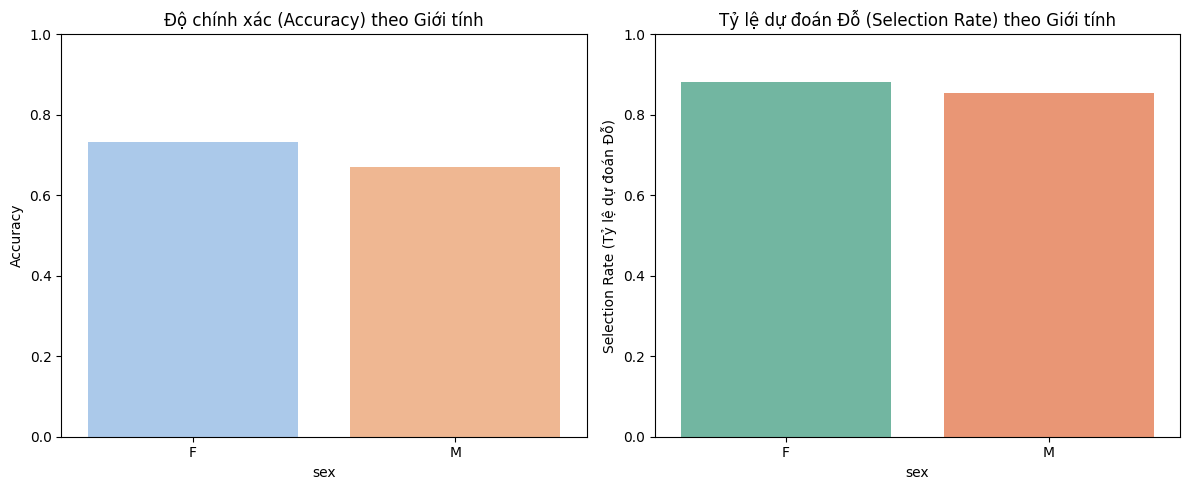

In [6]:
# Lấy dữ liệu từ metric_frame
by_group_df = metric_frame.by_group

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ 1: Accuracy theo Giới tính
sns.barplot(x=by_group_df.index, y=by_group_df['Accuracy'], ax=axes[0], palette='pastel')
axes[0].set_title('Độ chính xác (Accuracy) theo Giới tính')
axes[0].set_ylim(0, 1)

# Biểu đồ 2: Selection Rate (Tỷ lệ cho qua môn) theo Giới tính
sns.barplot(x=by_group_df.index, y=by_group_df['Selection Rate (Tỷ lệ dự đoán Đỗ)'], ax=axes[1], palette='Set2')
axes[1].set_title('Tỷ lệ dự đoán Đỗ (Selection Rate) theo Giới tính')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()